# Gap Safe Screening Rules for Lasso
## Benchmark `LassoCV` with Leukemia Dataset
The Leukemia dataset hat 72 observations (rows) and 7'129 features (columns).
### Generate Benchmark Data
The code here needs to be run with different versions of scikit-learn.
If you use a conda environment, you can do
- `conda install scikit-learn=1.7`
- Run the below code cells
- `conda install scikit-learn=1.8`
- Restart notebook
- Run the below code cells
- Proceed with plotting

In [ ]:
from pathlib import Path
import time
import numpy as np
import polars as pl
import seaborn as sns
import sklearn
from sklearn.datasets import fetch_openml
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_name = "2026-04-20_results_leukemia.csv"

In [2]:
X, y = fetch_openml("leukemia", version=1, return_X_y=True)
n_samples, n_features = X.shape

# Because we apply a penalty, we standarize X (zero mean and unit variance).
X = StandardScaler().fit_transform(X)
X = np.asfortranarray(X)  # Lasso prefers Fortran-contiguous 
y = LabelEncoder().fit_transform(y)
print(f"{n_samples=} {n_features=}")

n_samples=72 n_features=7129


In [3]:
n_alphas = 100
tols = [1e-2, 1e-3, 1e-4]

timing = np.zeros(len(tols))
for tol_ix, tol in enumerate(tols):
    t0 = time.time()
    m = LassoCV(alphas=n_alphas, tol=tol).fit(X, y)
    timing[tol_ix] = time.time() - t0

df = pl.DataFrame({"tolerance": tols, "time": timing, "version": sklearn.__version__})
if Path(file_name).exists():
    df2 = pl.read_csv(file_name)
    df = pl.concat([df, df2])

df.write_csv(file_name)

### Plot Benchmark

[Text(0.5, 1.0, 'LassoCV on Leukemia'), Text(0, 0.5, 'time [seconds]')]

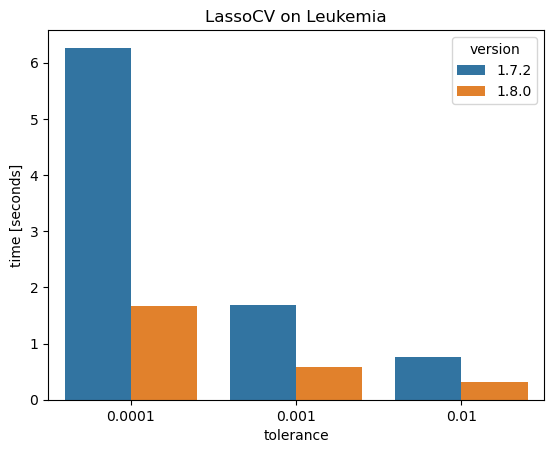

In [3]:
df = pl.read_csv(file_name)
sns.barplot(
    df, x="tolerance", y="time", hue="version", hue_order=["1.7.2", "1.8.0"],
    legend=True
).set(title="LassoCV on Leukemia", ylabel="time [seconds]")

[Text(0.5, 1.0, 'Speedup 1.8 vs 1.7 of LassoCV on Leukemia')]

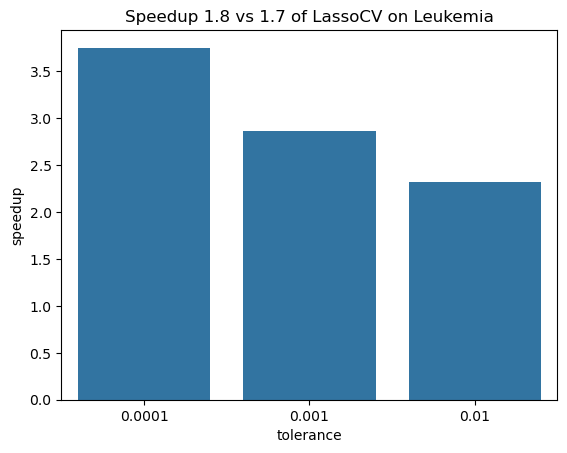

In [5]:
sns.barplot(
    df
    .pivot(on="version", index="tolerance")
    .select("tolerance", speedup=pl.col("1.7.2")/pl.col("1.8.0")),
    x="tolerance",
    y="speedup",
).set(title="Speedup 1.8 vs 1.7 of LassoCV on Leukemia")

## Benchmark `Lasso` on E2006-log1p data
This dataset is sometimes called "finance". It has 16,087 observations (rows) and 4,272,227 features (columns). It is also very sparse, only 0.14% of the matrix entries have a value (all others are considered as zero).
### Download Dataset

In [1]:
import pathlib
import shutil
import urllib.request

# The following two lines might be necessary for a successful download.
import truststore
truststore.inject_into_ssl()

url = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/regression/log1p.E2006.train.bz2"
file_name = pathlib.Path(url).name

if not pathlib.Path(file_name).exists():
    with urllib.request.urlopen(url) as response:
        # if you only want to keep it in a temporary file
        # import tempfile
        # with tempfile.NamedTemporaryFile(delete=False) as tmp_file:
        #     shutil.copyfileobj(response, tmp_file)
        with open(file_name, "wb") as file:
            shutil.copyfileobj(response, file)

### Generate Benchmark Data
Same as above, this needs to be run with different versions of scikit-learn.

In [ ]:
from pathlib import Path
import time
import numpy as np
import polars as pl
from scipy import sparse
import seaborn as sns
import sklearn
from sklearn.datasets import load_svmlight_file
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

file_name_data = "log1p.E2006.train.bz2"
file_name = "2026-04-20_results_finance.csv"

In [2]:
X, y = load_svmlight_file(file_name_data)
n_samples, n_features = X.shape

# Because we apply a penalty, we standarize X (unit variance).
# Data is sparse, therefore no mean centering.
X = StandardScaler(with_mean=False).fit_transform(X)
X = sparse.csc_array(X)  # Lasso prefers CSC sparse instread of CSR.
print(f"{n_samples=} {n_features=}")
print(f"Sparsity of X is {X.nnz / (n_samples * n_features)}.")

n_samples=16087 n_features=4272227
Sparsity of X is 0.0014074729668371701.


In [4]:
n_alphas = 100
alphas = [1e-1, 1e-2, 1e-3]

timing = np.zeros(len(alphas))
gap = np.zeros(len(alphas))
nnz_coef = np.zeros(len(alphas))
for tol_ix, alpha in enumerate(alphas):
    t0 = time.time()
    m = Lasso(alpha=alpha).fit(X, y)
    timing[tol_ix] = time.time() - t0
    gap[tol_ix] = m.dual_gap_
    nnz_coef[tol_ix] = np.sum(m.coef_ != 0)

df = pl.DataFrame({
    "alpha": alphas,
    "time": timing,
    "version": sklearn.__version__,
    "gap": gap,
    "nnz_coef": nnz_coef,
})
if Path(file_name).exists():
    df2 = pl.read_csv(file_name)
    df = pl.concat([df, df2])

df.write_csv(file_name)

Now the same with Celer.

In [ ]:
import celer

n_alphas = 100
alphas = [1e-1, 1e-2, 1e-3]

timing = np.zeros(len(alphas))
gap = np.zeros(len(alphas))
nnz_coef = np.zeros(len(alphas))
for tol_ix, alpha in enumerate(alphas):
    t0 = time.time()
    m = celer.Lasso(alpha=alpha).fit(X, y)
    timing[tol_ix] = time.time() - t0
    gap[tol_ix] = m.dual_gap_
    nnz_coef[tol_ix] = np.sum(m.coef_ != 0)

df = pl.DataFrame({
    "alpha": alphas,
    "time": timing,
    "version": "celer",
    "gap": gap,
    "nnz_coef": nnz_coef,
})
if Path(file_name).exists():
    df2 = pl.read_csv(file_name)
    df = pl.concat([df, df2])

df.write_csv(file_name)

Now with skglm.

In [ ]:
import skglm
import numpy as np

# skglm does does provide the gual gap
def dual_gap(X, y, intercept_, coef_, alpha):
    n = X.shape[0]
    R = y - X @ coef_ - intercept_
    R2 = np.linalg.norm(R)**2
    primal = 1/(2 * n) * R2 + alpha * np.linalg.norm(coef_, ord=1)
    # theta = R
    Xt_theta = X.T @ R
    dual_norm_Xt_theta = np.linalg.norm(Xt_theta, ord=np.inf)
    if (dual_norm_Xt_theta > n * alpha):
        scale = n * alpha / dual_norm_Xt_theta
    else:
        scale = 1.0
    dual = -1/(2 * n) * (scale ** 2) * R2 + scale/n * R @ (y - intercept_)
    return primal - dual

n_alphas = 100
alphas = [1e-1, 1e-2, 1e-3]

timing = np.zeros(len(alphas))
gap = np.zeros(len(alphas))
nnz_coef = np.zeros(len(alphas))
for tol_ix, alpha in enumerate(alphas):
    t0 = time.time()
    m = skglm.Lasso(alpha=alpha).fit(X, y)
    timing[tol_ix] = time.time() - t0
    gap[tol_ix] = dual_gap(X, y, m.intercept_, m.coef_, alpha=alpha)
    nnz_coef[tol_ix] = np.sum(m.coef_ != 0)

df = pl.DataFrame({
    "alpha": alphas,
    "time": timing,
    "version": "skglm",
    "gap": gap,
    "nnz_coef": nnz_coef,
})
if Path(file_name).exists():
    df2 = pl.read_csv(file_name)
    df = pl.concat([df, df2])

df.write_csv(file_name)

### Plot Benchmark

[Text(0.5, 1.0, 'Lasso on E2006-log1p'), Text(0, 0.5, 'time [seconds]')]

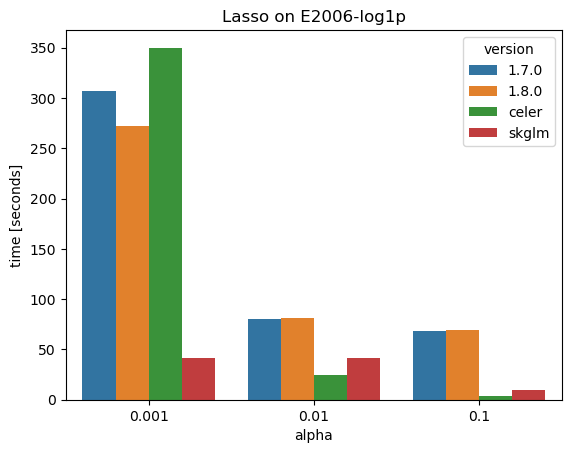

In [ ]:
df = pl.read_csv(file_name)
sns.barplot(
    df, x="alpha", y="time", hue="version",
    hue_order=["1.7.0", "1.8.0", "celer", "skglm"], legend=True
).set(title="Lasso on E2006-log1p", ylabel="time [seconds]")

[Text(0.5, 1.0, 'Lasso on E2006-log1p'),
 Text(0, 0.5, 'Number of non-zero coefficients')]

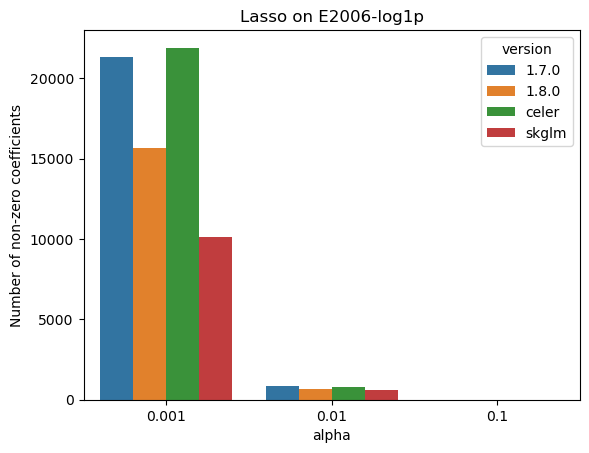

In [15]:
df = pl.read_csv(file_name)
sns.barplot(
    df, x="alpha", y="nnz_coef", hue="version",
    hue_order=["1.7.0", "1.8.0", "celer", "skglm"], legend=True
).set(title="Lasso on E2006-log1p", ylabel="Number of non-zero coefficients")